In [ ]:
from pathlib import Path

# Subject ID
subid = "0001"

# Base directories
udel_dir = Path("/home/oana/UDel")
udel_subj = udel_dir/f"U01_UDEL_{subid}_01_v3"
udel_anatomy = udel_subj/f"U01_UDEL_{subid}_01_SLANT"
fs_dir = udel_dir / "fsruns" / subid
mre_dir = Path("/home/oana/MRE_analysis") / subid


# MRE volumes
mre_files = {
    "stiffness": mre_dir / "MRE_stiffness_in_T1_space.nii.gz",
    "real": mre_dir / "MRE_real_in_T1_space.nii.gz",
    "imag": mre_dir / "MRE_imag_in_T1_space.nii.gz",
}

# T1W and T2w paths for myelin calculation
t1w_path = mre_dir/"T1_MNI_in_fs_space.nii.gz"
t2w_path = mre_dir/"T2_MNI_in_fs_space.nii.gz"

#Brain mask for skul stripping
brainmask_path = mre_dir /"brainmask_fs.nii.gz"


In [ ]:
import numpy as np
import nibabel as nib
from cortech import Cortex
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
from cortech.visualization import FsPlotter
from cortech.interactive_visualization import InteractivePlotter

cortex = Cortex.from_freesurfer_subject_dir(fs_dir, pial="pial.T1", registration="sphere.reg")

# smooth white/pial surfaces
#for hemi in [cortex.lh, cortex.rh]:
#    hemi.white.smooth_taubin(n_iter=5, inplace=True)
#    hemi.pial.smooth_taubin(n_iter=5, inplace=True)

# estimate central surface
mid_layers = {
    "lh": cortex.lh.estimate_layers(method="equivolume", frac=0.5, curv_kwargs={'smooth_iter': 10}, return_surface=True),
    "rh": cortex.rh.estimate_layers(method="equivolume", frac=0.5, curv_kwargs={'smooth_iter': 10}, return_surface=True)
}


# interpolate all MRE data
surface_mre = {}

for name, vol_path in mre_files.items():
    img = nib.load(str(vol_path))
    data = img.get_fdata()
    affine = img.affine

    surface_mre[name] = {hemi: mid_layers[hemi].interpolate_to_nodes(data, affine) for hemi in ["lh", "rh"]}


# Myelin map
t1_img = nib.load(str(t1w_path))
t2_img = nib.load(str(t2w_path))
#mask_img = nib.load(str(brainmask_path))

t1_data = t1_img.get_fdata()
t2_data = t2_img.get_fdata()
#mask_data = mask_img.get_fdata().astype(bool)

t1_affine = t1_img.affine

mask_img = nib.load(str(brainmask_path))
mask_data = mask_img.get_fdata()
mask_binary = mask_data > 0  # inside brain

t1_masked = np.where(mask_binary, t1_data, 0)
t2_masked = np.where(mask_binary, t2_data, 0)

#compute ratio only there both images arep positive
valid = (t1_masked > 0) & (t2_masked > 0)
myelin_data = np.where(valid, t1_masked/(t2_masked + 1e-3), 0)

# Interpolate myelin map to surface
surface_myelin = {hemi: mid_layers[hemi].interpolate_to_nodes(myelin_data, t1_affine) for hemi in ["lh", "rh"]}

#Load parcellation
aparc = {
    "lh": nib.freesurfer.io.read_annot(fs_dir / "label" / "lh.aparc.a2009s.annot"),
    "rh": nib.freesurfer.io.read_annot(fs_dir / "label" / "rh.aparc.a2009s.annot"),
}

#Add geometry parameters

from nibabel.freesurfer import read_morph_data

curvature = {
    "lh": read_morph_data(fs_dir / "surf" / "lh.curv"),
    "rh": read_morph_data(fs_dir / "surf" / "rh.curv"),
}


thickness = {
    "lh": read_morph_data(fs_dir / "surf" / "lh.thickness"),
    "rh": read_morph_data(fs_dir / "surf" / "rh.thickness"),
}

sulcal_depth = {
    "lh": read_morph_data(fs_dir / "surf" / "lh.sulc"),
    "rh": read_morph_data(fs_dir / "surf" / "rh.sulc"),
}


In [ ]:
myelinimage=nib.Nifti1Image(myelin_data,t1_affine)
nib.save(myelinimage,mre_dir/'Myelin.nii.gz')

### Vertex-wise analysis per regions

In [4]:
import pandas as pd

stiff_min=99 

for hemi in ["lh","rh"]:
    labels, ctab, names = aparc[hemi]
    labels = labels.astype(int)

    #Extract hemi specific arrays
    curv = curvature[hemi].astype(np.float64)
    thick= thickness[hemi].astype(np.float64)
    stiff = surface_mre["stiffness"][hemi].astype(np.float64)
    real = surface_mre["real"][hemi].astype(np.float64) #shear real (storage modulus)
    imag = surface_mre["imag"][hemi].astype(np.float64) #shear imaginar (loss modulus)
    sulc =sulcal_depth[hemi].astype(np.float64)
    myelin = surface_myelin[hemi].astype(np.float64)

    #Stiffness mask that eliminates values around zero
    stiff_mask=(np.isfinite(stiff) & (stiff >= stiff_min))

    #Apply the mask to the other 
    curv_m=curv[stiff_mask]
    thick_m=thick[stiff_mask]
    stiff_m = stiff[stiff_mask]
    real_m =real[stiff_mask]
    imag_m = imag[stiff_mask]
    sulc_m =sulc[stiff_mask]
    myelin_m=myelin[stiff_mask]
    labels_m=labels[stiff_mask]

    names= np.array([n.decode("utf-8") for n in names])
    #Transform shear stiffness, storage modulus and loss modulus to kPa
    stiff_kpa = stiff_m/1000
    real_kpa = real_m/1000
    imag_kpa = imag_m/1000

    #Create a DataFrame 
    df = pd.DataFrame({
        "curvature":curv_m,
        "thickness":thick_m,
        "sulcal_depth":sulc_m,
        "stiffness":stiff_kpa,
        "real":real_kpa,
        "imag":imag_kpa,
        "myelin":myelin_m,
        "label":labels_m,
    })

    df["parcel"]=df["label"].map({i:names[i] for i in range(len(names))})
df.head()


,curvature,thickness,sulcal_depth,stiffness,real,imag,myelin,label,parcel
0,-0.076381,2.733513,-4.104676,0.149998,0.126377,0.064278,0.527922,43,Pole_occipital
1,-0.109680,2.197700,-5.186806,0.108453,0.068527,0.064107,0.569056,43,Pole_occipital
2,-0.317661,2.030369,-6.008362,0.130512,0.094126,0.070193,0.437101,43,Pole_occipital
3,-0.274947,2.255861,-6.151323,0.101734,0.069711,0.057153,0.434860,43,Pole_occipital
4,-0.044668,2.824182,-3.661626,0.251696,0.207358,0.113128,0.524651,43,Pole_occipital


In [5]:
from scipy.stats import spearmanr
results=[]

for parcel, g in df.groupby("parcel"):
    if len(g)<50:
        continue

    r,p=spearmanr(g["stiffness"],g["sulcal_depth"],nan_policy="omit")

    results.append({
        "parcel":parcel,
        "n_vertices":len(g),
        "r_val":r,
        "p_val":p
    })

parcel_stats=pd.DataFrame(results)
parcel_stats.sort_values("r_val",ascending=True)

,parcel,n_vertices,r_val,p_val
48,S_circular_insula_sup,1730,-0.552156,1.207775e-138
39,Lat_Fis-ant-Vertical,227,-0.330580,3.446638e-07
19,G_oc-temp_med-Lingual,3456,-0.258559,6.645302e-54
30,G_rectus,727,-0.237899,8.197643e-11
38,Lat_Fis-ant-Horizont,515,-0.233557,8.244291e-08
...,...,...,...,...
60,S_occipital_ant,842,0.655692,1.292853e-104
72,S_temporal_sup,8095,0.660509,0.000000e+00
49,S_collat_transv_ant,1213,0.666125,2.043078e-156
7,G_and_S_subcentral,1778,0.716902,1.566859e-280


In [6]:
from statsmodels.stats.multitest import multipletests

parcel_stats["p_fdr"]=multipletests(parcel_stats["p_val"],method="fdr_bh")[1]
parcel_stats.sort_values("p_fdr",ascending=True)

,parcel,n_vertices,r_val,p_val,p_fdr
5,G_and_S_occipital_inf,1426,0.887543,0.000000e+00,0.000000e+00
16,G_front_sup,6771,0.489447,0.000000e+00,0.000000e+00
51,S_front_inf,3236,0.644219,0.000000e+00,0.000000e+00
72,S_temporal_sup,8095,0.660509,0.000000e+00,0.000000e+00
7,G_and_S_subcentral,1778,0.716902,1.566859e-280,2.318952e-279
...,...,...,...,...,...
10,G_cingul-Post-ventral,339,-0.060390,2.675115e-01,2.749424e-01
12,G_front_inf-Opercular,1541,-0.028377,2.655963e-01,2.749424e-01
62,S_orbital_lateral,615,0.044830,2.669749e-01,2.749424e-01
11,G_cuneus,2510,0.017317,3.858222e-01,3.911074e-01


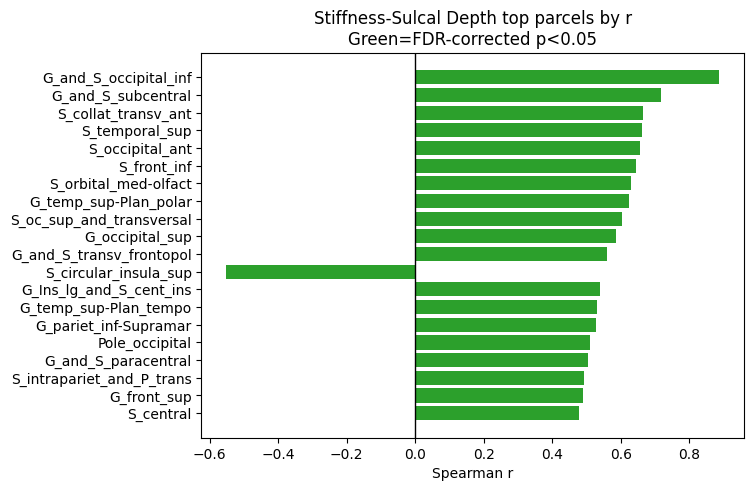

In [7]:
parcel_stats["abs_r"]=parcel_stats["r_val"].abs()
top=parcel_stats.sort_values("abs_r",ascending=False).head(20)
colors=["tab:green" if p<0.05 else "tab:red" for p in top["p_fdr"]]

plt.figure(figsize=(7,5))
plt.barh(top["parcel"],top["r_val"], color=colors)
plt.axvline(0,color="k",lw=1)
plt.xlabel("Spearman r")
plt.title("Stiffness-Sulcal Depth top parcels by r\nGreen=FDR-corrected p<0.05")
plt.gca().invert_yaxis()
plt.show()

In [8]:
mechanical={
    "stiffness":"stiffness",
    "storage":"real",
    "loss":"imag",
    "myelin":"myelin",
}
geometric={
    #"curvature":"curvature",
    "thickness":"thickness",
    "sulcal_depth":"sulcal_depth",
    "curvature":"curvature",
    "myelin":"myelin"
}

from scipy.stats import spearmanr
results=[]

for parcel, g in df.groupby("parcel"):

    if len(g)<50:
        continue

    for mech_name, mech_col in mechanical.items():
        for geom_name, geom_col in geometric.items():
            
            x=g[mech_col]
            y=g[geom_col]
            

            r,p=spearmanr(x,y)

            results.append({
                "parcel":parcel,
                "mechanical":mech_name,
                "geometric":geom_name,
                "r_val":r,
                "p_val":p
            })

corr_df=pd.DataFrame(results)
corr_df.sort_values("r_val",ascending=False)

,parcel,mechanical,geometric,r_val,p_val
47,G_and_S_cingul-Mid-Ant,myelin,myelin,1.000000,0.000000e+00
703,S_calcarine,myelin,myelin,1.000000,0.000000e+00
687,Pole_temporal,myelin,myelin,1.000000,0.000000e+00
719,S_central,myelin,myelin,1.000000,0.000000e+00
1183,S_temporal_transverse,myelin,myelin,1.000000,0.000000e+00
...,...,...,...,...,...
212,G_front_inf-Orbital,storage,thickness,-0.673079,1.449927e-68
1177,S_temporal_transverse,loss,sulcal_depth,-0.696312,6.221191e-42
636,Lat_Fis-ant-Vertical,myelin,thickness,-0.707304,9.566253e-36
617,Lat_Fis-ant-Horizont,loss,sulcal_depth,-0.708758,9.103356e-80


In [48]:
from statsmodels.stats.multitest import multipletests

corr_df["p_fdr"] = np.nan

for (mech, geom), idx in corr_df.groupby(["mechanical", "geometric"]).groups.items():

    pvals = corr_df.loc[idx, "p_val"]
    corr_df.loc[idx, "p_fdr"] = multipletests(pvals, method="fdr_bh")[1]


In [49]:
corr_df.sort_values("p_fdr",ascending=True)

,parcel,mechanical,geometric,r_val,p_val,p_fdr
716,S_central,myelin,thickness,0.681153,0.000000,0.000000
719,S_central,myelin,myelin,1.000000,0.000000,0.000000
351,G_occipital_middle,myelin,myelin,1.000000,0.000000,0.000000
1087,S_precentral-inf-part,myelin,myelin,1.000000,0.000000,0.000000
1157,S_temporal_sup,storage,sulcal_depth,0.707489,0.000000,0.000000
...,...,...,...,...,...,...
1015,S_orbital_med-olfact,storage,myelin,0.005414,0.871361,0.871361
195,G_front_inf-Opercular,stiffness,myelin,0.003163,0.901273,0.901273
109,G_and_S_paracentral,myelin,sulcal_depth,-0.002046,0.944826,0.957769
173,G_cingul-Post-ventral,myelin,sulcal_depth,0.001442,0.978903,0.978903


In [50]:
#Summary of statistically reliable parcels
summary = (
    corr_df
    .query("p_fdr < 0.05")
    .groupby(["mechanical", "geometric"])
    .agg(mean_r_values=("r_val", "mean"))
    .unstack()
)
print(summary)

           mean_r_values                                 
geometric      curvature    myelin sulcal_depth thickness
mechanical                                               
loss            0.272823  0.039715     0.270528 -0.111826
myelin          0.284578  1.000000     0.106405 -0.243044
stiffness       0.271781  0.082086     0.296540 -0.102442
storage         0.261260  0.088109     0.288466 -0.116956


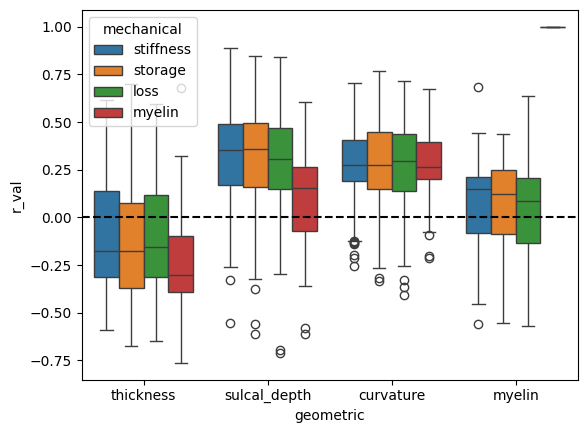

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sig = corr_df.query("p_fdr < 0.05")

sns.boxplot(
    data=sig,
    x="geometric",
    y="r_val",
    hue="mechanical"
)
plt.axhline(0, color="k", linestyle="--")
plt.show()


### Region-wise mean analysis

In [52]:
import pandas as pd

stiff_min=99 #Pa (=0.099 kPa)
rows=[]
for hemi in ["lh","rh"]:
    labels, ctab, names =aparc[hemi]
    #Extract hemi specific arrays
    curv = curvature[hemi]
    thick= thickness[hemi]
    stiff = surface_mre["stiffness"][hemi]
    real = surface_mre["real"][hemi] #shear real (storage modulus)
    imag = surface_mre["imag"][hemi]  #shear imaginar (loss modulus)
    sulc =sulcal_depth[hemi]
    myelin = surface_myelin[hemi]


    for lab_id, lab_name in enumerate(names):
        if lab_name ==b'unknown':
            continue

        mask= (labels == lab_id) & (stiff >= stiff_min)

        if mask.sum()<50:
            continue
        
        rows.append({
            "region":lab_name.decode(),
            "curvature":np.mean(curv[mask]),
            "thickness":np.mean(thick[mask]),
            "sulcal_depth":np.mean(sulc[mask]),
            "stiffness":np.mean(stiff[mask])/ 1000,
            "real":np.mean(real[mask])/ 1000,
            "imag":np.mean(imag[mask])/ 1000,
            "myelin":np.mean(myelin[mask]),
        })

    #Create a DataFrame 
    df_regions = pd.DataFrame(rows)

df_regions.head()
 


,region,curvature,thickness,sulcal_depth,stiffness,real,imag,myelin
0,G_and_S_frontomargin,-0.023328,2.344673,-1.872500,2.718772,2.207921,1.179323,0.510478
1,G_and_S_occipital_inf,-0.038680,2.501883,-2.363351,2.226325,1.705700,1.099567,0.486725
2,G_and_S_paracentral,-0.062279,2.413852,-3.852975,2.260427,2.173588,0.373337,0.564752
3,G_and_S_subcentral,-0.066269,3.082231,-4.045073,3.017226,2.415781,1.403587,0.429092
4,G_and_S_transv_frontopol,-0.135851,2.653771,-6.474117,2.752262,2.287666,1.168347,0.454646


In [53]:
df_regions.describe()

,curvature,thickness,sulcal_depth,stiffness,real,imag,myelin
count,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000
mean,-0.010504,2.597291,0.432203,2.883732,2.430371,1.120208,0.478609
std,0.087300,0.415944,4.054347,0.533926,0.589650,0.306804,0.035236
min,-0.148897,1.626127,-6.474117,1.776743,1.480053,0.210894,0.400037
25%,-0.099245,2.321760,-3.602498,2.499616,2.010598,0.960236,0.461179
50%,-0.001294,2.604105,0.670253,2.813886,2.362912,1.147239,0.476100
75%,0.072442,2.863231,3.883898,3.253743,2.733001,1.311146,0.497732
max,0.129556,4.035236,10.665398,4.560660,4.359676,2.007843,0.607308


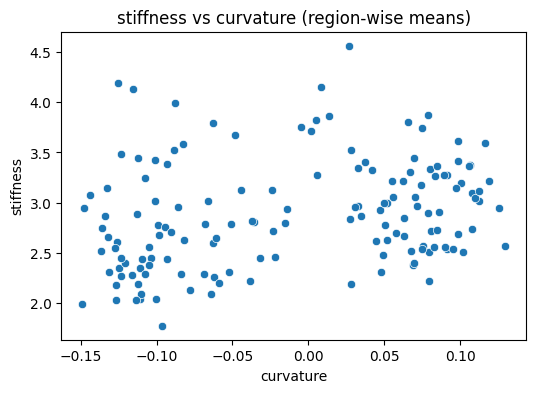

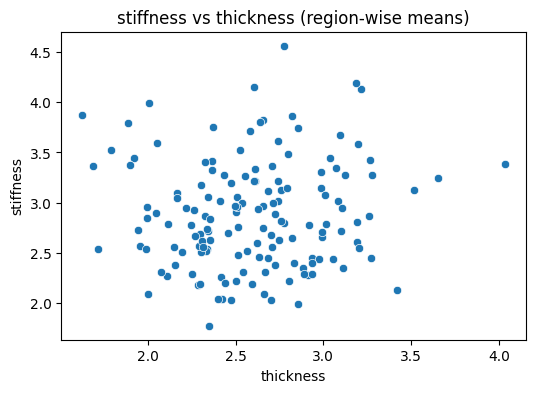

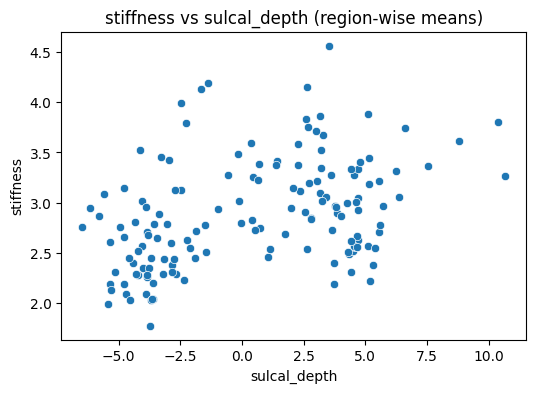

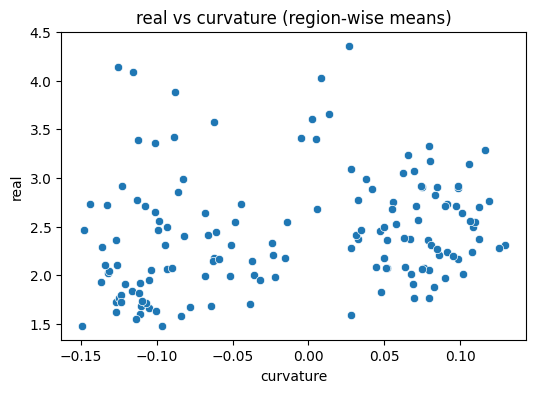

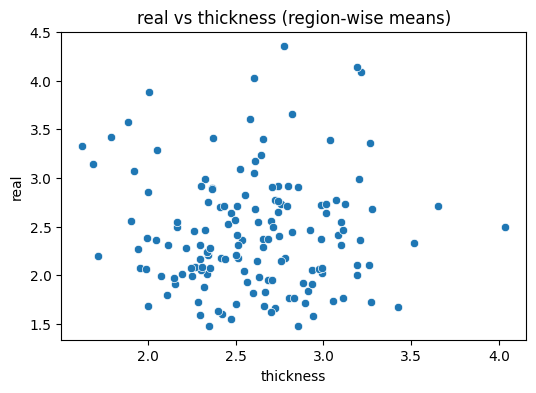

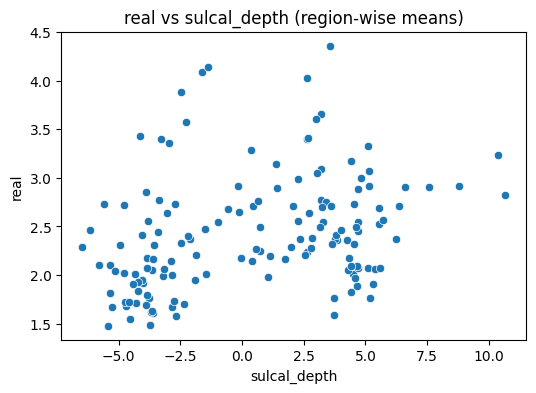

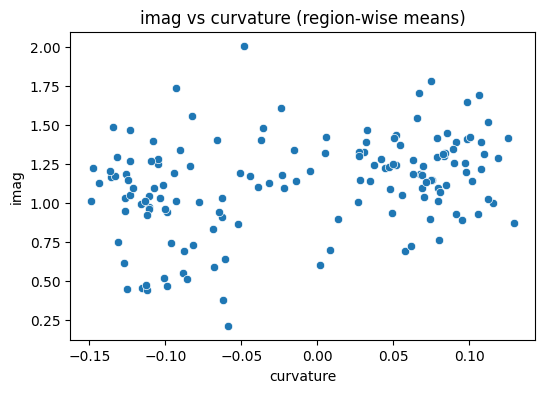

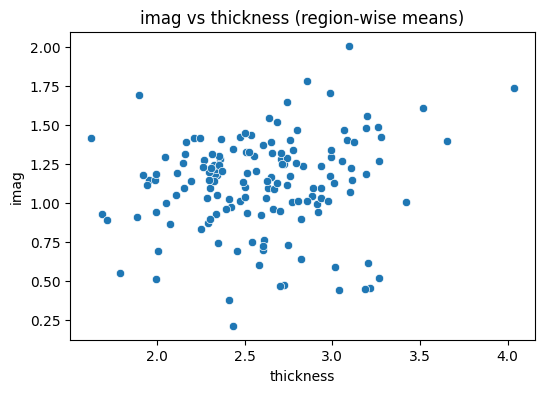

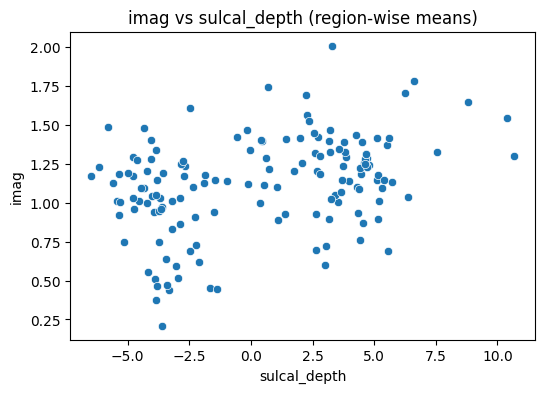

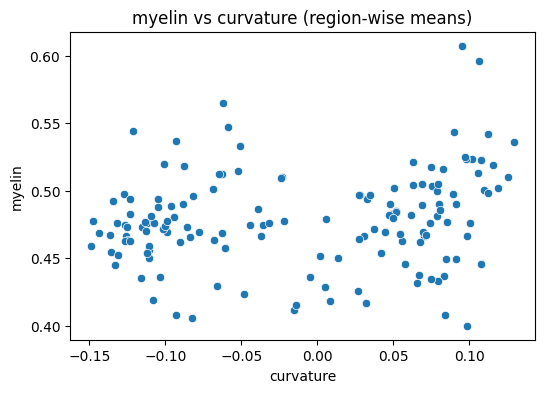

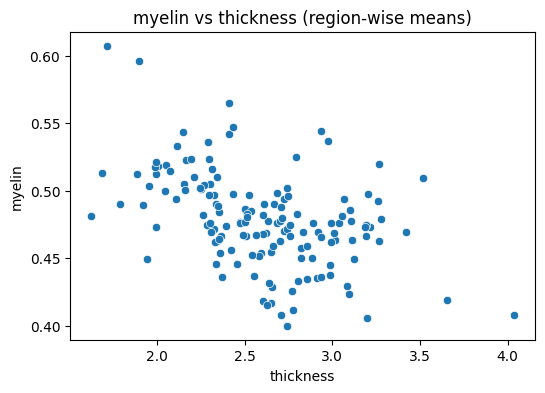

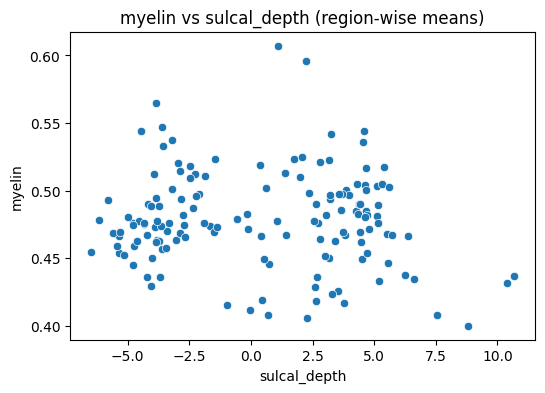

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

mechanical = ["stiffness", "real", "imag", "myelin"]
geometric = ["curvature", "thickness", "sulcal_depth"]

for mech in mechanical:
    for geom in geometric:
        plt.figure(figsize=(6,4))
        sns.scatterplot(data=df_regions, x=geom, y=mech)
        plt.xlabel(geom)
        plt.ylabel(mech)
        plt.title(f"{mech} vs {geom} (region-wise means)")
        plt.show()

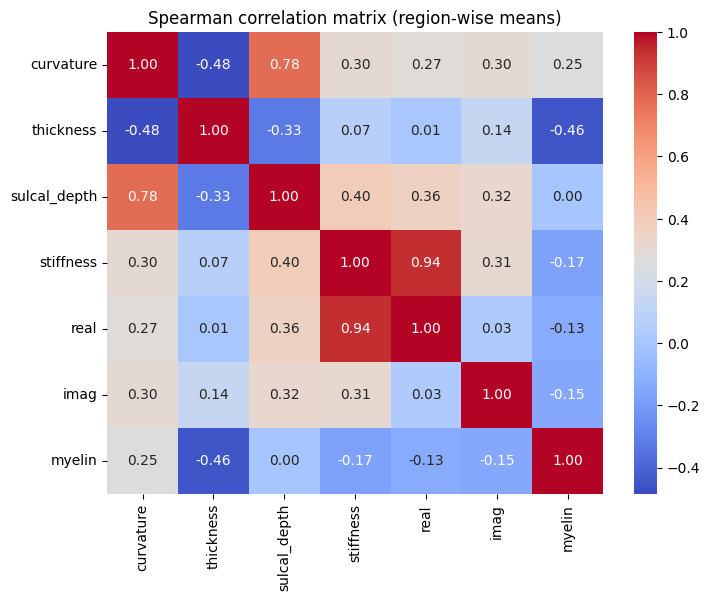

In [41]:
import numpy as np

corr_s = df_regions[geometric+mechanical].corr(method="spearman")

plt.figure(figsize=(8,6))
sns.heatmap(corr_s, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Spearman correlation matrix (region-wise means)")
plt.show()

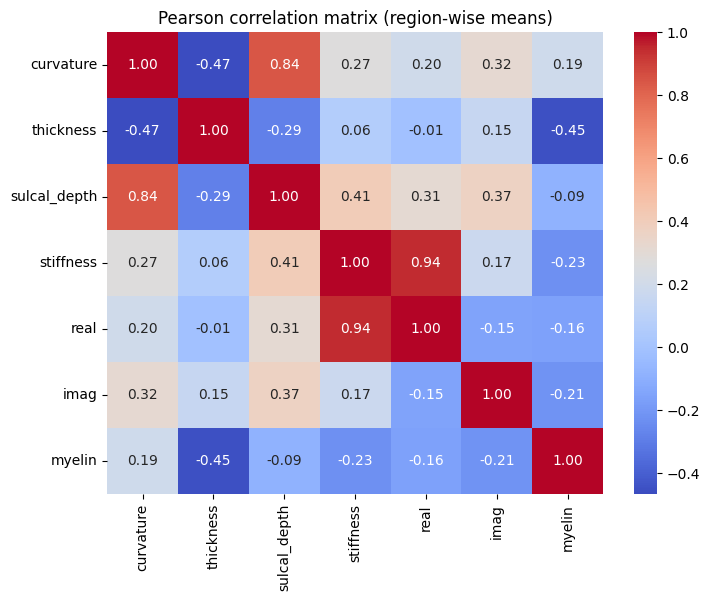

In [42]:
import numpy as np

corr_s = df_regions[geometric+mechanical].corr(method="pearson")

plt.figure(figsize=(8,6))
sns.heatmap(corr_s, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Pearson correlation matrix (region-wise means)")
plt.show()

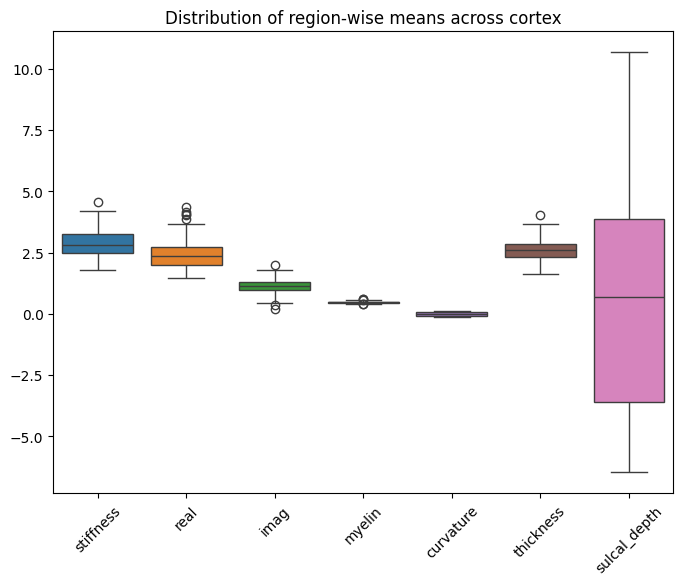

In [43]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df_regions[mechanical + geometric])
plt.xticks(rotation=45)
plt.title("Distribution of region-wise means across cortex")
plt.show()

In [44]:
import statsmodels.api as sm
x=df_regions[["stiffness","real","imag","myelin"]]
x=sm.add_constant(x)
y=df_regions["curvature"]

model=sm.OLS(y,x).fit()
print("curvature ~ stiffness + real + imag +myelin")
print(model.summary())

curvature ~ stiffness + real + imag +myelin
                            OLS Regression Results                            
Dep. Variable:              curvature   R-squared:                       0.333
Model:                            OLS   Adj. R-squared:                  0.314
Method:                 Least Squares   F-statistic:                     17.83
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           6.75e-12
Time:                        14:41:24   Log-Likelihood:                 181.33
No. Observations:                 148   AIC:                            -352.7
Df Residuals:                     143   BIC:                            -337.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const   

In [45]:
import statsmodels.api as sm
x=df_regions[["stiffness","real","imag","myelin"]]
x=sm.add_constant(x)
y=df_regions["thickness"]

model=sm.OLS(y,x).fit()
print("thickness ~ stiffness + real + imag +myelin")
print(model.summary())

thickness ~ stiffness + real + imag +myelin
                            OLS Regression Results                            
Dep. Variable:              thickness   R-squared:                       0.299
Model:                            OLS   Adj. R-squared:                  0.279
Method:                 Least Squares   F-statistic:                     15.24
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           2.12e-10
Time:                        14:42:00   Log-Likelihood:                -53.404
No. Observations:                 148   AIC:                             116.8
Df Residuals:                     143   BIC:                             131.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const   

In [46]:
import statsmodels.api as sm
x=df_regions[["stiffness","real","imag","myelin"]]
x=sm.add_constant(x)
y=df_regions["sulcal_depth"]

model=sm.OLS(y,x).fit()
print("sulcal depth ~ stiffness + real + imag +myelin")
print(model.summary())

sulcal depth ~ stiffness + real + imag +myelin
                            OLS Regression Results                            
Dep. Variable:           sulcal_depth   R-squared:                       0.320
Model:                            OLS   Adj. R-squared:                  0.301
Method:                 Least Squares   F-statistic:                     16.82
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           2.55e-11
Time:                        14:42:21   Log-Likelihood:                -388.14
No. Observations:                 148   AIC:                             786.3
Df Residuals:                     143   BIC:                             801.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const

In [47]:
import statsmodels.api as sm
x=df_regions[["curvature","thickness","sulcal_depth","myelin"]]
x=sm.add_constant(x)
y=df_regions["stiffness"]

model=sm.OLS(y,x).fit()
print("stiffness ~ curvature + thickness + sulcal_depth +myelin")
print(model.summary())

stiffness ~ curvature + thickness + sulcal_depth +myelin
                            OLS Regression Results                            
Dep. Variable:              stiffness   R-squared:                       0.212
Model:                            OLS   Adj. R-squared:                  0.190
Method:                 Least Squares   F-statistic:                     9.644
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           6.21e-07
Time:                        14:42:53   Log-Likelihood:                -98.958
No. Observations:                 148   AIC:                             207.9
Df Residuals:                     143   BIC:                             222.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------